# Across-Datasets 2-Class — CNN-ResBiGRU Arm Curl vs Bench Press Classifier

**Based on:** Mekruksavanich & Jitpattanakul (2024), *Appl. Syst. Innov.*, 7(4), 59.

**Goal:** train a 2-class classifier on ** arm curls from one dataset and  bench presses from another**, then evaluate on a completely different dataset that contains **10 different exercise variants**. This notebook asks:

> *Can a model trained on only Barbell Curls (from Lean) and Flat Barbell Bench Press (from MyoGym) correctly classify all 10 exercise variants in OurData as either "Arm Curl" or "Bench Press"?*

This is a much harder test than the within-participant or within-dataset notebooks, because it stacks **two generalization challenges**:

1. **Cross-dataset generalization.** Different labs, sensors, collection protocols, mounting orientations. Then OurData is a third collection environment entirely.
2. **Cross-variant generalization.** Training only sees one specific curl variant `(1,3)` Barbell Curls and one specific bench variant `(5,5)` Flat Barbell Bench Press. At test time the model must classify Preacher Curls, Decline Dumbbell Press, Reverse Barbell Curls, and seven other variants it has never seen, into the correct parent class. It has to learn what "curl-ness" and "bench-ness" look like in a way that generalizes beyond the specific variants it trained on.
3. **Cross-participant generalization.** The participants from MyoGym, Lean, and OurData all consist of multiple participants

**Training source:** `golden_dataset_v10_20Hz.csv` — filtered to Lean's `(1,3)` and MyoGym's `(5,5)` only.

**Test source:** `OurData_v5_scaled_20Hz.csv` — all 10 exercise variants, all 5 participants.

---
## 1. Imports and setup

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import re, os, warnings
warnings.filterwarnings("ignore")
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")

PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda


---
## 2. Configuration

**Training data filter:**
- From golden: only `(parent=1, child=3)` Barbell Curls from Lean AND `(parent=5, child=5)` Flat Barbell Bench Press from MyoGym
- Any `dataset == "ourdata"` rows in golden are dropped (redundant with the separate OurData file)

**Test data:** all of `OurData_v5_scaled_20Hz.csv` — all 10 variants from all 5 participants.

**Validation holdout:** one random ID from Lean's `(1,3)` pool + one random ID from MyoGym's `(5,5)` pool. This is used for early-stopping only. Using a fixed number of IDs (rather than a fixed number of participants or windows) keeps the val set size predictable regardless of how long each recording happens to be.

In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# -- Data paths --
GOLDEN_DATA_PATH_REL = "data/golden_dataset_v10_20Hz.csv"
OUR_DATA_PATH_REL    = "data/OurData_v5_scaled_20Hz.csv"

# Auto-detect sampling rate from golden filename; verify OurData matches.
_hz_match = re.search(r"(\d+)\s*Hz", GOLDEN_DATA_PATH_REL, re.IGNORECASE)
if _hz_match is None:
    raise ValueError(
        f"Could not find sampling rate in GOLDEN_DATA_PATH_REL: {GOLDEN_DATA_PATH_REL}"
    )
SAMPLING_RATE = int(_hz_match.group(1))

# -- 2-class setup --
LABEL_MAP   = {1: 0, 5: 1}          # parent value -> model label
NUM_CLASSES = 2
class_names = ["Arm Curl", "Bench Press"]

# -- 10 exercise names for per-variant breakdown (OurData test set only) --
EXERCISE_NAMES = {
    (1, 1):  "Alternate Dumbbell Curls",
    (1, 2):  "Preacher Curls",
    (1, 3):  "Barbell Curls",
    (1, 4):  "Reverse Barbell Curls",
    (5, 5):  "Flat Barbell Bench Press",
    (5, 6):  "Incline Barbell Bench Press",
    (5, 7):  "Decline Barbell Bench Press",
    (5, 8):  "Flat Dumbbell Bench Press",
    (5, 9):  "Incline Dumbbell Bench Press",
    (5, 10): "Decline Dumbbell Bench Press",
}

# -- Training filter (what gets kept from the golden dataset) --
LEAN_CURL_FILTER    = {"dataset": "lean",    "parent": 1, "child": 3}
MYOGYM_BENCH_FILTER = {"dataset": "myogym",  "parent": 5, "child": 5}

# -- Preprocessing --
WINDOW_SIZE_SEC = 2.0
OVERLAP         = 0.5

# -- Training --
EPOCHS     = 100
BATCH_SIZE = 64
LEARNING_RATE = 0.001
PATIENCE   = 20

# -- Ablation: channel mode --
CHANNEL_MODE = "accel_AND_gyro"

if CHANNEL_MODE == "accel_AND_gyro":
    IMU_COLS = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
elif CHANNEL_MODE == "accel_only":
    IMU_COLS = ["x_accel", "y_accel", "z_accel"]
elif CHANNEL_MODE == "gyro_only":
    IMU_COLS = ["x_gyro", "y_gyro", "z_gyro"]
else:
    raise ValueError(f"Unknown CHANNEL_MODE: {CHANNEL_MODE}")

NUM_IMU_CHANNELS = len(IMU_COLS)

# -- Derived --
_window_samples = int(WINDOW_SIZE_SEC * SAMPLING_RATE)

LOWCUT  = 0.3
HIGHCUT = min(15.0, 0.4 * SAMPLING_RATE)
binding = "Nyquist-bound" if 0.4 * SAMPLING_RATE < 15.0 else "physiology-bound"

CONV_FILTERS  = (64, 128, 256, 512)
N_CONV_BLOCKS = len(CONV_FILTERS)

print(f"Sampling rate:      {SAMPLING_RATE} Hz")
print(f"Channel mode:       {CHANNEL_MODE}  ({NUM_IMU_CHANNELS} channels)")
print(f"Bandpass:           {LOWCUT}-{HIGHCUT} Hz  ({binding})")
print(f"Window samples:     {_window_samples}")
print(f"CNN conv blocks:    {N_CONV_BLOCKS}  (filters={CONV_FILTERS})")
print(f"Post-CNN seq len:   8  (fixed by AdaptiveAvgPool1d)")
print(f"Training filter:    Lean (1,3) curls + MyoGym (5,5) bench press")
print(f"Test set:           All of OurData (10 variants, 5 participants)")
print(f"Val holdout:        1 random ID from each training class")
print(f"Early stopping:     patience={PATIENCE} on the 2-ID val set")

Sampling rate:      20 Hz
Channel mode:       accel_AND_gyro  (6 channels)
Bandpass:           0.3-8.0 Hz  (Nyquist-bound)
Window samples:     40
CNN conv blocks:    4  (filters=(64, 128, 256, 512))
Post-CNN seq len:   8  (fixed by AdaptiveAvgPool1d)
Training filter:    Lean (1,3) curls + MyoGym (5,5) bench press
Test set:           All of OurData (10 variants, 5 participants)
Val holdout:        1 random ID from each training class
Early stopping:     patience=20 on the 2-ID val set


---
## 3. Mount Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model"
GOLDEN_FULL_PATH = os.path.join(BASE_PATH, GOLDEN_DATA_PATH_REL)
OUR_FULL_PATH    = os.path.join(BASE_PATH, OUR_DATA_PATH_REL)

print(f"Golden:  {GOLDEN_FULL_PATH}")
print(f"OurData: {OUR_FULL_PATH}")

Golden:  /content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/golden_dataset_v10_20Hz.csv
OurData: /content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/OurData_v5_scaled_20Hz.csv


---
## 4. Load both files, convert units, filter

Three steps:

**4a.** Load both files separately. Print schema and value counts so we can see what we're working with.

**4b.** Per-file unit conversion — the two datasets store acceleration in different units:
- `golden_dataset_v10_20Hz.csv` — no `"scaled"` marker → convert G's to m/s² (multiply by 9.81)
- `OurData_v5_scaled_20Hz.csv` — has `"scaled"` in the filename → already in m/s², skip conversion

Both conversions are idempotent (guarded by `df.attrs["accel_in_ms2"]`) so re-running is safe.

**4c.** Gyro sanity check. We print both files' gyro ranges here so we can spot any unit mismatch before training.

**4d.** Filter golden to training rows only: Lean `(1,3)` curls + MyoGym `(5,5)` bench press. Print ID counts so we can verify the val holdout will be a small fraction of the training pool.

**4e.** Namespace IDs with `"g_"` / `"o_"` prefixes so `groupby("ID")` in preprocessing does not combine unrelated recordings together.

**4f.** Assign binary labels from the `parent` column to both files.

In [ ]:
# ---- 4a. Load both files ----
print("Loading golden dataset...")
df_golden = pd.read_csv(GOLDEN_FULL_PATH)
print(f"  Golden:  {df_golden.shape[0]:,} rows, {df_golden.shape[1]} columns")
print(f"  Columns: {list(df_golden.columns)}")
print(f"\n  `dataset` value counts in golden:")
print(df_golden["dataset"].value_counts().to_string())

print("\nLoading OurData...")
df_our = pd.read_csv(OUR_FULL_PATH)
print(f"  OurData: {df_our.shape[0]:,} rows, {df_our.shape[1]} columns")
print(f"  Columns: {list(df_our.columns)}")

# Sampling rate match check
_our_hz = re.search(r"(\d+)\s*Hz", OUR_DATA_PATH_REL, re.IGNORECASE)
if _our_hz is None or int(_our_hz.group(1)) != SAMPLING_RATE:
    raise ValueError(
        f"Sampling-rate mismatch: golden says {SAMPLING_RATE} Hz, "
        f"OurData filename is {OUR_DATA_PATH_REL}."
    )

Loading golden dataset...
  Golden:  24,788 rows, 12 columns
  Columns: ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID', 'dataset']

  `dataset` value counts in golden:
dataset
ourdata    9891
lean       9668
myogym     5229

Loading OurData...
  OurData: 52,828 rows, 11 columns
  Columns: ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID']


In [ ]:
# ---- 4b. Per-file accel unit conversion (idempotent) ----
ACCEL_COLS = ["x_accel", "y_accel", "z_accel"]

def maybe_convert_accel(df, path, name):
    """Convert G's to m/s^2 only if (a) filename lacks 'scaled' marker AND
    (b) the attrs flag isn't already set. Idempotent."""
    if "scaled" in path.lower() or df.attrs.get("accel_in_ms2", False):
        print(f"  {name}: skipping G->m/s^2 conversion (already in m/s^2).")
        df.attrs["accel_in_ms2"] = True   # ensure flag set so downstream cells don't re-convert
    else:
        print(f"  {name}: converting acceleration from G's to m/s^2...")
        df[ACCEL_COLS] = df[ACCEL_COLS] * 9.81
        df.attrs["accel_in_ms2"] = True
    print(f"    {name} accel range: "
          f"[{df[ACCEL_COLS].min().min():.2f}, "
          f"{df[ACCEL_COLS].max().max():.2f}] m/s^2")

print("Per-file accel unit conversion:")
maybe_convert_accel(df_golden, GOLDEN_DATA_PATH_REL, "Golden ")
maybe_convert_accel(df_our,    OUR_DATA_PATH_REL,    "OurData")

Per-file accel unit conversion:
  Golden : converting acceleration from G's to m/s^2...
    Golden  accel range: [-10.11, 12.61] m/s^2
  OurData: skipping G->m/s^2 conversion (already in m/s^2).
    OurData accel range: [-12.04, 11.10] m/s^2


In [ ]:
# ---- 4c. Gyro unit sanity check ----
# If both files are in the same unit (e.g. deg/s), their ranges should be comparable.
# If one is in rad/s, its range will be ~57x smaller (= 180/pi).
GYRO_COLS = ["x_gyro", "y_gyro", "z_gyro"]

golden_gyro_max = df_golden[GYRO_COLS].abs().max().max()
our_gyro_max    = df_our[GYRO_COLS].abs().max().max()

print("Gyro range sanity check:")
print(f"  Golden  max |gyro|: {golden_gyro_max:.2f}")
print(f"  OurData max |gyro|: {our_gyro_max:.2f}")
print(f"  Ratio (golden/our): {golden_gyro_max / max(our_gyro_max, 1e-9):.2f}x")

# Rough heuristic: if ratio is 30-100, one is probably rad/s and the other deg/s
ratio = golden_gyro_max / max(our_gyro_max, 1e-9)
if 0.02 < ratio < 0.1 or 10 < ratio < 100:
    print(f"\n  ⚠️  WARNING: gyro ranges differ by ~{ratio:.1f}x, which is suspicious.")
    print(f"     Possible rad/s vs deg/s unit mismatch. Investigate before training.")
else:
    print(f"\n  Gyro ranges look consistent between files.")

Gyro range sanity check:
  Golden  max |gyro|: 252.74
  OurData max |gyro|: 511.96
  Ratio (golden/our): 0.49x

  Gyro ranges look consistent between files.


In [ ]:
# ---- 4d. Filter golden to training pool only ----
# Lean (1,3) curls only — Lean's (1,3) is the only exercise Lean has, but we still
# assert the filter explicitly so any unexpected rows get caught loudly.
lean_curl_mask = (
    (df_golden["dataset"] == LEAN_CURL_FILTER["dataset"]) &
    (df_golden["parent"]  == LEAN_CURL_FILTER["parent"])  &
    (df_golden["child"]   == LEAN_CURL_FILTER["child"])
)
myogym_bench_mask = (
    (df_golden["dataset"] == MYOGYM_BENCH_FILTER["dataset"]) &
    (df_golden["parent"]  == MYOGYM_BENCH_FILTER["parent"])  &
    (df_golden["child"]   == MYOGYM_BENCH_FILTER["child"])
)

df_train_raw = df_golden[lean_curl_mask | myogym_bench_mask].copy().reset_index(drop=True)
print(f"Training pool (after filter): {df_train_raw.shape[0]:,} rows")

# Inventory: how many IDs, participants, rows per class?
print(f"\nTraining pool breakdown:")
for lbl, filt, name in [(0, lean_curl_mask, "Lean (1,3)    curls"),
                        (1, myogym_bench_mask, "MyoGym (5,5)  bench press")]:
    sub = df_golden[filt]
    n_ids   = sub["ID"].nunique()
    n_parts = sub["participant"].nunique()
    n_rows  = len(sub)
    print(f"  {name}: {n_rows:>6,} rows  |  {n_ids} unique IDs  |  {n_parts} participants")

if df_train_raw.shape[0] == 0:
    raise ValueError("Training filter returned 0 rows. Check dataset/parent/child values.")

Training pool (after filter): 14,897 rows

Training pool breakdown:
  Lean (1,3)    curls:  9,668 rows  |  13 unique IDs  |  4 participants
  MyoGym (5,5)  bench press:  5,229 rows  |  10 unique IDs  |  10 participants


In [ ]:
# ---- 4e. Namespace IDs to prevent collisions ----
df_train_raw["ID"] = "g_" + df_train_raw["ID"].astype(str)
df_our["ID"]       = "o_" + df_our["ID"].astype(str)

# ---- 4f. Attach binary labels from parent column ----
for d, name in [(df_train_raw, "Training pool"), (df_our, "OurData")]:
    d["label"] = d["parent"].astype(int).map(LABEL_MAP)
    unmapped = d["label"].isna().sum()
    if unmapped > 0:
        bad = d.loc[d["label"].isna(), "parent"].unique()
        raise ValueError(f"{name}: {unmapped} rows have unmapped parent values: {bad}")
    d["label"] = d["label"].astype(np.int64)

# Propagate the m/s^2 flag onto the filtered training frame so downstream
# code doesn't try to re-convert.
df_train_raw.attrs["accel_in_ms2"] = True

print(f"Training pool after filter + labels:")
for lbl in range(NUM_CLASSES):
    rows = (df_train_raw["label"] == lbl).sum()
    ids  = df_train_raw[df_train_raw["label"] == lbl]["ID"].nunique()
    print(f"  {class_names[lbl]:>12s} (label {lbl}): {rows:>6,} rows  |  {ids} IDs")

print(f"\nOurData (test set):")
print(f"  Participants: {sorted(df_our['participant'].unique())}")
for lbl in range(NUM_CLASSES):
    rows = (df_our["label"] == lbl).sum()
    ids  = df_our[df_our["label"] == lbl]["ID"].nunique()
    print(f"  {class_names[lbl]:>12s} (label {lbl}): {rows:>6,} rows  |  {ids} IDs")

print(f"\n(parent, child) pairs in OurData:")
pair_counts = (df_our.groupby(["parent", "child"]).size()
               .reset_index(name="rows").sort_values(["parent", "child"]))
print(pair_counts.to_string(index=False))

Training pool after filter + labels:
      Arm Curl (label 0):  9,668 rows  |  13 IDs
   Bench Press (label 1):  5,229 rows  |  10 IDs

OurData (test set):
  Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
      Arm Curl (label 0): 22,100 rows  |  38 IDs
   Bench Press (label 1): 30,728 rows  |  60 IDs

(parent, child) pairs in OurData:
 parent  child  rows
      1      1  5273
      1      2  5595
      1      3  5535
      1      4  5697
      5      5  4356
      5      6  5247
      5      7  4529
      5      8  5629
      5      9  5425
      5     10  5542


---
## 5. Preprocessing pipeline

`IMUPreprocessor` is unchanged: per-ID Butterworth bandpass + sliding-window segmentation. `segment_by_id` returns `(X, y, participants, ids, children)` — we carry `child` through so the final results table can break down OurData accuracy per exercise variant.

In [ ]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU data.

    Steps (in order):
      1. Denoise per ID  -- zero-phase Butterworth bandpass, per channel,
                            applied independently to each recording so the
                            filter never smears across ID boundaries.
      2. Segment per ID  -- sliding window with majority-vote labels.

    Normalization is NOT done here. It must be fit on training data only,
    so it lives outside this class.
    """

    def __init__(self, sampling_rate=20, window_size_sec=2.0, overlap=0.5,
                 lowcut=0.3, highcut=8.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)
        self.step_size = int(self.window_size * (1.0 - overlap))
        self.lowcut = lowcut
        self.highcut = highcut
        self.filter_order = filter_order

        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            raise ValueError(
                f"Invalid filter band: lowcut={self.lowcut}, "
                f"highcut={self.highcut}, fs={self.fs}"
            )
        self._b, self._a = butter(self.filter_order, [lo, hi], btype="band")
        self._min_filt_len = 3 * max(len(self._b), len(self._a))

        print(f"  Sampling rate:  {self.fs} Hz")
        print(f"  Nyquist:        {nyq} Hz")
        print(f"  Bandpass:       {self.lowcut}-{self.highcut} Hz")
        print(f"  Window size:    {self.window_size} samples ({window_size_sec}s)")
        print(f"  Step size:      {self.step_size} samples ({overlap*100:.0f}% overlap)")

    def denoise(self, data):
        out = np.zeros_like(data, dtype=np.float64)
        for ch in range(data.shape[1]):
            if data.shape[0] > self._min_filt_len:
                out[:, ch] = filtfilt(self._b, self._a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]
        return out

    def segment_single(self, data, labels):
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            X.append(window)
            y.append(vals[cnts.argmax()])
        return X, y

    def segment_by_id(self, df, imu_cols, label_col="label", id_col="ID",
                      participant_col="participant", child_col="child"):
        """
        For each ID: denoise that ID's IMU array, then sliding-window it.
        Returns:
            X:            (N, window_size, channels) -- denoised, NOT normalized
            y:            (N,)    -- binary parent-class label
            participants: (N,)
            ids:          (N,)    -- which ID each window came from
            children:     (N,)    -- which child (specific exercise) each window came from
        """
        all_X, all_y, all_parts, all_ids, all_children = [], [], [], [], []

        for uid in df[id_col].unique():
            subset = df[df[id_col] == uid]
            imu = subset[imu_cols].values.astype(np.float64)
            labels = subset[label_col].values
            participant = subset[participant_col].iloc[0]
            child = subset[child_col].iloc[0]

            if len(imu) < self.window_size:
                continue

            imu = self.denoise(imu)
            windows, window_labels = self.segment_single(imu, labels)

            all_X.extend(windows)
            all_y.extend(window_labels)
            all_parts.extend([participant] * len(windows))
            all_ids.extend([uid] * len(windows))
            all_children.extend([child] * len(windows))

        return (np.array(all_X, dtype=np.float32),
                np.array(all_y, dtype=np.int64),
                np.array(all_parts),
                np.array(all_ids),
                np.array(all_children))


class MinMaxScaler3D:
    """Per-channel min-max scaler for arrays shaped (N_windows, T, C)."""
    def fit(self, X):
        self.min_ = X.min(axis=(0, 1))
        self.max_ = X.max(axis=(0, 1))
        denom = self.max_ - self.min_
        denom[denom == 0] = 1.0
        self._denom = denom
        return self

    def transform(self, X):
        out = (X - self.min_) / self._denom
        return np.clip(out, 0.0, 1.0).astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

---
## 6. Preprocess both datasets

Run the pipeline separately on the filtered training pool and on the full OurData. Normalization is **not** fit here — it happens in Section 8 after we carve out the val set, so it's fit on training windows only.

In [ ]:
print("Initializing preprocessor...")
pp = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
    lowcut=LOWCUT,
    highcut=HIGHCUT,
)

print("\nSegmenting training pool (golden: Lean curls + MyoGym bench)...")
X_train_pool, y_train_pool, parts_train_pool, ids_train_pool, _child_train_pool = \
    pp.segment_by_id(df_train_raw, IMU_COLS)

print(f"  X_train_pool: {X_train_pool.shape}")
print(f"  Windows per class:")
for lbl in range(NUM_CLASSES):
    print(f"    {class_names[lbl]:>12s} (label {lbl}): {(y_train_pool == lbl).sum():>5d} windows")
print(f"  Unique training IDs: {len(np.unique(ids_train_pool))}")

print("\nSegmenting OurData (test set)...")
X_test, y_test, parts_test, ids_test, children_test = \
    pp.segment_by_id(df_our, IMU_COLS)

print(f"  X_test: {X_test.shape}")
print(f"  Windows per class:")
for lbl in range(NUM_CLASSES):
    print(f"    {class_names[lbl]:>12s} (label {lbl}): {(y_test == lbl).sum():>5d} windows")
print(f"  Unique OurData IDs: {len(np.unique(ids_test))}")

Initializing preprocessor...
  Sampling rate:  20 Hz
  Nyquist:        10.0 Hz
  Bandpass:       0.3-8.0 Hz
  Window size:    40 samples (2.0s)
  Step size:      20 samples (50% overlap)

Segmenting training pool (golden: Lean curls + MyoGym bench)...
  X_train_pool: (711, 40, 6)
  Windows per class:
        Arm Curl (label 0):   464 windows
     Bench Press (label 1):   247 windows
  Unique training IDs: 23

Segmenting OurData (test set)...
  X_test: (2493, 40, 6)
  Windows per class:
        Arm Curl (label 0):  1046 windows
     Bench Press (label 1):  1447 windows
  Unique OurData IDs: 98


---
## 7. Model: CNN-ResBiGRU

Identical architecture to every other notebook in this project.

In [ ]:
class ResBiGRUBlock(nn.Module):
    def __init__(self, input_dim, hidden=128, n_layers=2):
        super().__init__()
        self.blocks = nn.ModuleList()
        dim = input_dim
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "gru":  nn.GRU(dim, hidden, batch_first=True, bidirectional=True),
                "proj": nn.Linear(dim, hidden * 2, bias=False),
                "ln":   nn.LayerNorm(hidden * 2),
            }))
            dim = hidden * 2

    def forward(self, x):
        for blk in self.blocks:
            h, _ = blk["gru"](x)
            r = blk["proj"](x)
            x = blk["ln"](r + h)
        return x


class CNNResBiGRU(nn.Module):
    def __init__(self, in_channels=6, num_classes=2,
                 conv_filters=(64, 128, 256, 512), kernel=3,
                 conv_drop=0.3, gru_units=128, gru_layers=2, dense=128,
                 post_cnn_len=8):
        super().__init__()

        conv_list = []
        ch = in_channels
        for f in conv_filters:
            conv_list.extend([
                nn.Conv1d(ch, f, kernel, padding=kernel // 2),
                nn.BatchNorm1d(f),
                nn.ReLU(),
                nn.Dropout(conv_drop),
            ])
            ch = f
        self.conv = nn.Sequential(*conv_list)

        self.adaptive_pool = nn.AdaptiveAvgPool1d(post_cnn_len)

        self.resbigru = ResBiGRUBlock(ch, gru_units, gru_layers)
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(dense, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = self.adaptive_pool(x)
        x = x.permute(0, 2, 1)
        x = self.resbigru(x)
        x = x.mean(dim=1)
        return self.head(x)

In [ ]:
_test_model = CNNResBiGRU(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
    conv_filters=CONV_FILTERS,
).to(DEVICE)
_test_input = torch.randn(2, pp.window_size, NUM_IMU_CHANNELS).to(DEVICE)
_test_output = _test_model(_test_input)

n_params = sum(p.numel() for p in _test_model.parameters())
print(f"Input shape:  {tuple(_test_input.shape)}")
print(f"Output shape: {tuple(_test_output.shape)}  (expecting last dim = {NUM_CLASSES})")
print(f"Parameters:   {n_params:,}")

del _test_model, _test_input, _test_output

Input shape:  (2, 40, 6)
Output shape: (2, 2)  (expecting last dim = 2)
Parameters:   1,540,418


---
## 8. Train/val split + normalization

**Val set:** one randomly chosen ID from each training class (1 Lean curl ID + 1 MyoGym bench ID), held out for early stopping only. This is a small fraction of the training pool — the data printed in Section 4d should confirm this.

**Why 1 ID per class (not 1 participant):** a participant who did a 30-minute recording contributes dramatically more windows than one who did 5 minutes, which makes val-set size unpredictable. Holding out a fixed number of IDs instead keeps the val size comparable regardless of session length.

**Normalization:** `MinMaxScaler3D` is fit on the training windows only (after the val split), then applied to val AND to the OurData test set. The OurData values will likely fall partly outside [0, 1] since it's a different collection environment — `MinMaxScaler3D.transform` clips to [0, 1], which is a known mild domain-shift artifact and not a bug.

In [ ]:
# ============================================================
# Val split: 1 random ID from each class
# ============================================================
val_rng = np.random.default_rng(SEED)

curl_ids  = np.unique(ids_train_pool[y_train_pool == 0])
bench_ids = np.unique(ids_train_pool[y_train_pool == 1])

val_curl_id  = val_rng.choice(curl_ids,  size=1, replace=False)[0]
val_bench_id = val_rng.choice(bench_ids, size=1, replace=False)[0]
val_ids      = np.array([val_curl_id, val_bench_id])

val_mask   = np.isin(ids_train_pool, val_ids)
train_mask = ~val_mask

X_train_raw = X_train_pool[train_mask]
y_train     = y_train_pool[train_mask]
X_val_raw   = X_train_pool[val_mask]
y_val       = y_train_pool[val_mask]

print(f"Val IDs chosen:  curl={val_curl_id}, bench={val_bench_id}")
print(f"Training: {X_train_raw.shape[0]} windows "
      f"({(y_train == 0).sum()} curl + {(y_train == 1).sum()} bench)")
print(f"Val:      {X_val_raw.shape[0]} windows "
      f"({(y_val == 0).sum()} curl + {(y_val == 1).sum()} bench)")
print(f"Test:     {X_test.shape[0]} windows (OurData, all variants)")

# ============================================================
# Normalization: fit on training windows only
# ============================================================
scaler = MinMaxScaler3D().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test_norm = scaler.transform(X_test)

print(f"\nNormalized ranges:")
print(f"  Train: [{X_train.min():.3f}, {X_train.max():.3f}]  "
      f"(should be exactly [0.000, 1.000] by construction)")
print(f"  Val:   [{X_val.min():.3f}, {X_val.max():.3f}]  "
      f"(should sit inside [0, 1])")
print(f"  Test:  [{X_test_norm.min():.3f}, {X_test_norm.max():.3f}]  "
      f"(expect OurData to push against the 0/1 clipping boundaries — that's domain shift)")

# Clipping diagnostic for the test set: what fraction of values got clipped?
clipped_frac = ((X_test_norm == 0) | (X_test_norm == 1)).mean()
print(f"\n  Fraction of OurData values clipped to 0 or 1: {clipped_frac*100:.2f}%")
print(f"  (Higher = more domain shift between training distribution and OurData)")

Val IDs chosen:  curl=g_12, bench=g_7
Training: 653 windows (426 curl + 227 bench)
Val:      58 windows (38 curl + 20 bench)
Test:     2493 windows (OurData, all variants)

Normalized ranges:
  Train: [0.000, 1.000]  (should be exactly [0.000, 1.000] by construction)
  Val:   [0.017, 0.910]  (should sit inside [0, 1])
  Test:  [0.000, 1.000]  (expect OurData to push against the 0/1 clipping boundaries — that's domain shift)

  Fraction of OurData values clipped to 0 or 1: 1.48%
  (Higher = more domain shift between training distribution and OurData)


---
## 9. Training function

In [ ]:
def train_model(model, X_tr, y_tr, X_va, y_va, device,
                epochs=100, batch_size=64, lr=1e-3, patience=20,
                verbose=True):
    """Train with early stopping; restore best-val-loss weights on return."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_va_t = torch.FloatTensor(X_va).to(device)
    y_va_t = torch.LongTensor(y_va).to(device)
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=batch_size, shuffle=True)

    best_val_loss, wait, best_state = float("inf"), 0, None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss   = loss_fn(val_logits, y_va_t).item()
            val_acc    = (val_logits.argmax(1) == y_va_t).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  "
                  f"train_loss={avg_train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_acc={val_acc:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.1e}")

        if val_loss < best_val_loss:
            best_val_loss, wait = val_loss, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    return model, history

---
## 10. Train the model

One training run on the filtered golden data. Early-stopped on the 2-ID val set.

In [ ]:
print(f"Training on {X_train.shape[0]} windows, validating on {X_val.shape[0]} windows")
print(f"Config: lr={LEARNING_RATE}, batch={BATCH_SIZE}, epochs={EPOCHS}, patience={PATIENCE}\n")

model = CNNResBiGRU(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
    conv_filters=CONV_FILTERS,
).to(DEVICE)

model, history = train_model(
    model, X_train, y_train, X_val, y_val,
    device=DEVICE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    patience=PATIENCE,
    verbose=True,
)

print("\nTraining complete.")

Training on 653 windows, validating on 58 windows
Config: lr=0.001, batch=64, epochs=100, patience=20

  Epoch  10  train_loss=0.0009  val_loss=0.0001  val_acc=1.0000  lr=1.0e-03
  Epoch  20  train_loss=0.0003  val_loss=0.0000  val_acc=1.0000  lr=5.0e-04
  Epoch  30  train_loss=0.0004  val_loss=0.0000  val_acc=1.0000  lr=5.0e-04
  Epoch  40  train_loss=0.0005  val_loss=0.0001  val_acc=1.0000  lr=2.5e-04
  Epoch  50  train_loss=0.0004  val_loss=0.0001  val_acc=1.0000  lr=6.3e-05
  Early stopping at epoch 51

Training complete.


---
## 11. Training-pool sanity check

Before testing on OurData, we check how well the model did on its **own training data** (the Lean curls + MyoGym bench it actually saw). This tells us whether the model learned the task at all.

**Interpretation:**
- **High train accuracy, high OurData accuracy:** the model learned AND generalized. Great.
- **High train accuracy, low OurData accuracy:** the model learned, but didn't transfer — this is the "domain shift" story. Clean result, expected if Lean/MyoGym/OurData collection environments differ.
- **Low train accuracy, low OurData accuracy:** something is wrong upstream (bad labels, bad preprocessing, unit mismatch, etc.) — investigate before trusting downstream numbers.

In [ ]:
model.eval()

# Training-set accuracy (just a sanity check — NOT a real metric)
with torch.no_grad():
    X_train_t = torch.FloatTensor(X_train).to(DEVICE)
    train_preds = model(X_train_t).argmax(1).cpu().numpy()
train_acc = accuracy_score(y_train, train_preds)

# Val-set accuracy (only 2 IDs worth)
with torch.no_grad():
    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    val_preds = model(X_val_t).argmax(1).cpu().numpy()
val_acc = accuracy_score(y_val, val_preds)

print(f"Training-pool sanity checks:")
print(f"  Train acc (on training data the model saw): {train_acc*100:.2f}%")
print(f"  Val acc   (on 2 held-out IDs):              {val_acc*100:.2f}%")
print(f"\n  If train acc is low, something's wrong with the pipeline upstream.")
print(f"  If train acc is high but OurData acc (next section) is low,")
print(f"  that's the domain-shift story we set out to measure.")

Training-pool sanity checks:
  Train acc (on training data the model saw): 100.00%
  Val acc   (on 2 held-out IDs):              100.00%

  If train acc is low, something's wrong with the pipeline upstream.
  If train acc is high but OurData acc (next section) is low,
  that's the domain-shift story we set out to measure.


---
## 12. Evaluate on OurData

The real test. Inference on every window in OurData, using the normalizer fit on Lean+MyoGym training data.

In [ ]:
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test_norm).to(DEVICE)
    test_preds = model(X_test_t).argmax(1).cpu().numpy()

test_acc  = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
test_rec  = recall_score(y_test, test_preds, average="macro", zero_division=0)
test_f1   = f1_score(y_test, test_preds, average="macro", zero_division=0)

print(f"{'='*55}")
print(f"  OURDATA TEST RESULTS (2-class, cross-dataset)")
print(f"{'='*55}")
print(f"  Accuracy:           {test_acc*100:.2f}%")
print(f"  Precision (macro):  {test_prec*100:.2f}%")
print(f"  Recall (macro):     {test_rec*100:.2f}%")
print(f"  F1 (macro):         {test_f1*100:.2f}%")
print(f"  Test windows:       {len(y_test)}")

print(f"\nClassification Report:")
print(classification_report(y_test, test_preds,
                            labels=[0, 1],
                            target_names=class_names,
                            digits=4, zero_division=0))

  OURDATA TEST RESULTS (2-class, cross-dataset)
  Accuracy:           88.01%
  Precision (macro):  90.28%
  Recall (macro):     86.07%
  F1 (macro):         87.14%
  Test windows:       2493

Classification Report:
              precision    recall  f1-score   support

    Arm Curl     0.9663    0.7400    0.8381      1046
 Bench Press     0.8392    0.9813    0.9047      1447

    accuracy                         0.8801      2493
   macro avg     0.9028    0.8607    0.8714      2493
weighted avg     0.8925    0.8801    0.8768      2493



---
## 13. Confusion matrix on OurData

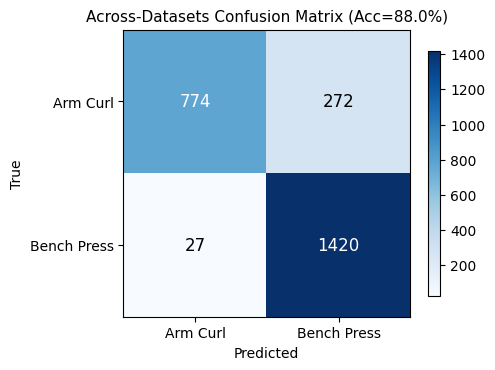

In [ ]:
cm = confusion_matrix(y_test, test_preds, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Across-Datasets Confusion Matrix (Acc={test_acc*100:.1f}%)",
             fontsize=11)

thresh = cm.max() / 2 if cm.max() > 0 else 0
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12)

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
## 14. Per-variant breakdown table

This is the interesting table. Training only saw **Barbell Curls** (the one specific curl variant from Lean) and **Flat Barbell Bench Press** (the one specific bench variant from MyoGym). But OurData contains **all 10 variants**. So for each of those 10, we ask: *"given that the model only ever trained on one specific curl and one specific bench (which are the standard parent classes), how well does it still recognize the variant as belonging to the correct parent class?"*

The table has 11 rows:
- 4 arm curl variants + 1 "Arm Curl Aggregate" row
- 6 bench press variants + 1 "Bench Press Aggregate" row
- 1 "Total" row at the bottom

### Why F1 is blank for individual exercises

F1 score combines two things: **precision** and **recall**.

- *Precision* answers: "of everything the model *labeled* 'bench press', what fraction actually was a bench press?"
- *Recall* answers: "of everything that actually *was* a bench press, what fraction did the model correctly label as 'bench press'?"

F1 is the harmonic mean of these two: `F1 = 2 × (P × R) / (P + R)`. Higher is better, capped at 1.0. It's a balanced measure of model quality, punishing a model that gets high precision by being overly conservative (labeling few things as positive) or high recall by being overly aggressive (labeling everything as positive).

But here's the catch: F1 only makes sense when the model can actually *make predictions* for the class in question. Our model is a **2-class classifier** — it outputs either "Arm Curl" or "Bench Press". It never outputs "Preacher Curls" specifically, or "Decline Dumbbell Press" specifically.

So when we ask "what's the F1 for Preacher Curls?", there's no good answer, because the model never explicitly labels things as "Preacher Curls" — it just labels them as "Arm Curl" (the parent class). The *precision* half of the F1 equation is undefined for individual variants.

What we *can* do per exercise is measure **recall**: of all the Preacher Curl windows in our test set, what fraction did the model correctly label as "Arm Curl"? And in the single-class case, recall equals accuracy. So the **Accuracy column already captures everything F1 would have told us** for individual exercises.

At the aggregate level (all curls vs all bench) and the total level, the binary framing is well-defined, so we compute F1 for those rows.

In [ ]:
# ============================================================
# Per-variant accuracy on OurData
# ============================================================
curl_pairs  = [(1, 1), (1, 2), (1, 3), (1, 4)]
bench_pairs = [(5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10)]

rows = []

def per_variant_acc(parent_val, child_val):
    """Accuracy on OurData windows matching this specific (parent, child)."""
    mask = (children_test == child_val) & (y_test == LABEL_MAP[parent_val])
    if mask.sum() == 0:
        return None, 0
    correct = (test_preds[mask] == y_test[mask]).sum()
    return correct / mask.sum(), int(mask.sum())

# Arm Curl per-variant rows
for p, c in curl_pairs:
    acc, n = per_variant_acc(p, c)
    rows.append({
        "Parent Class": "Arm Curl",
        "Exercise":     EXERCISE_NAMES[(p, c)],
        "N windows":    n,
        "Accuracy (%)": np.nan if acc is None else acc * 100,
        "F1 Score (%)": "",
    })

# Arm Curl aggregate: all curl windows in OurData, pooled
curl_mask = y_test == 0
curl_acc  = accuracy_score(y_test[curl_mask], test_preds[curl_mask])
curl_f1   = f1_score(y_test, test_preds, labels=[0, 1],
                     average=None, zero_division=0)[0]
rows.append({
    "Parent Class": "Arm Curl",
    "Exercise":     "Aggregate",
    "N windows":    int(curl_mask.sum()),
    "Accuracy (%)": curl_acc * 100,
    "F1 Score (%)": f"{curl_f1*100:.2f}",
})

# Bench Press per-variant rows
for p, c in bench_pairs:
    acc, n = per_variant_acc(p, c)
    rows.append({
        "Parent Class": "Bench Press",
        "Exercise":     EXERCISE_NAMES[(p, c)],
        "N windows":    n,
        "Accuracy (%)": np.nan if acc is None else acc * 100,
        "F1 Score (%)": "",
    })

# Bench aggregate
bench_mask = y_test == 1
bench_acc  = accuracy_score(y_test[bench_mask], test_preds[bench_mask])
bench_f1   = f1_score(y_test, test_preds, labels=[0, 1],
                      average=None, zero_division=0)[1]
rows.append({
    "Parent Class": "Bench Press",
    "Exercise":     "Aggregate",
    "N windows":    int(bench_mask.sum()),
    "Accuracy (%)": bench_acc * 100,
    "F1 Score (%)": f"{bench_f1*100:.2f}",
})

# Total
total_acc = accuracy_score(y_test, test_preds)
total_f1  = f1_score(y_test, test_preds, average="macro", zero_division=0)
rows.append({
    "Parent Class": "Total",
    "Exercise":     "Total",
    "N windows":    len(y_test),
    "Accuracy (%)": total_acc * 100,
    "F1 Score (%)": f"{total_f1*100:.2f}",
})

writeup_df = pd.DataFrame(rows)
writeup_df["Accuracy (%)"] = writeup_df["Accuracy (%)"].round(2)

print("Across-Datasets Per-Variant Results (CNN-ResBiGRU, 2-class)")
print("Training: Lean (1,3) curls + MyoGym (5,5) bench press")
print("Testing:  OurData — all 10 variants")
print("=" * 75)
display(writeup_df)

Across-Datasets Per-Variant Results (CNN-ResBiGRU, 2-class)
Training: Lean (1,3) curls + MyoGym (5,5) bench press
Testing:  OurData — all 10 variants


,Parent Class,Exercise,N windows,Accuracy (%),F1 Score (%)
0,Arm Curl,Alternate Dumbbell Curls,251,66.53,
1,Arm Curl,Preacher Curls,264,99.24,
2,Arm Curl,Barbell Curls,261,100.00,
3,Arm Curl,Reverse Barbell Curls,270,31.11,
4,Arm Curl,Aggregate,1046,74.00,83.81
5,Bench Press,Flat Barbell Bench Press,204,100.00,
6,Bench Press,Incline Barbell Bench Press,247,93.93,
7,Bench Press,Decline Barbell Bench Press,210,95.71,
8,Bench Press,Flat Dumbbell Bench Press,266,99.62,
9,Bench Press,Incline Dumbbell Bench Press,257,100.00,


---
## 15. Training curves

Training loss should drop steadily; val loss should dip and then flatten (or start rising slightly — that's when early stopping kicks in and snapshots the best weights).

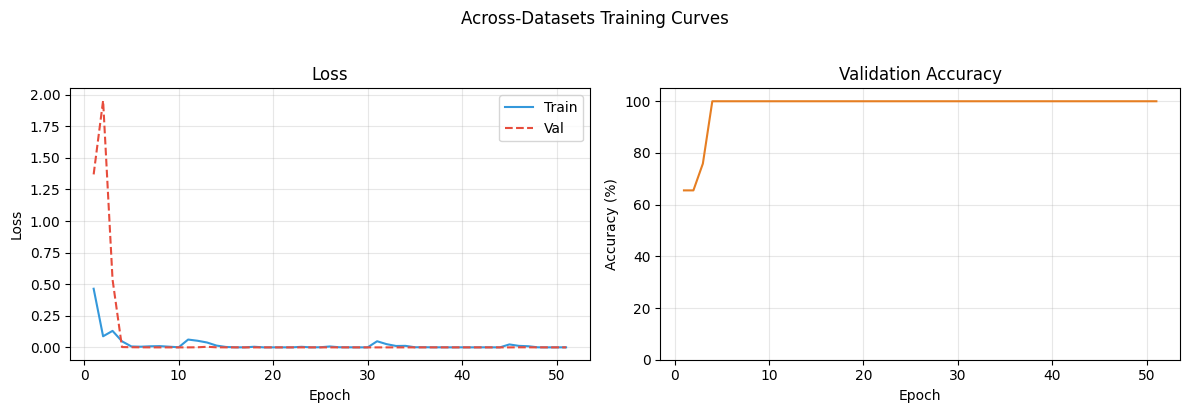

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"], label="Train", color="#3498db", linewidth=1.5)
axes[0].plot(ep, history["val_loss"],   label="Val",   color="#e74c3c", linewidth=1.5, linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, np.array(history["val_acc"]) * 100, color="#e67e22", linewidth=1.5)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Across-Datasets Training Curves", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()